<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Setup environment

We will install the latest `dev` branch of MONAI where the Restormer is available. Also, we use  `pip install` with the `BUILD_MONAI=1` flag. This will fetch the most recent source code from the MONAI repository's development branch, build MONAI's C++/CUDA extensions, and install the package.

Setting `env BUILD_MONAI=1` ensures that when calling the relevant Python modules, MONAI will prefer those extensions instead of the PyTorch/Python native implementations.

(The compilation may take a few to 10+ minutes.)

In [ ]:
!python -c "import monai" || pip install -q monai-weekly

env: BUILD_MONAI=1


## Setup imports

In [ ]:
from monai.utils import set_determinism, first
from monai.transforms import (
    EnsureChannelFirstD,
    Compose,
    LoadImageD,
    ScaleIntensityd,
    RandGaussianNoiseD,
    RandGaussianSmoothD,
)
from monai.config import print_config
from monai.data import DataLoader, Dataset, CacheDataset
from monai.networks.nets.restormer import Restormer
from monai.apps import MedNISTDataset
from monai.losses import SSIMLoss

import os
import torch
import matplotlib.pyplot as plt
import tempfile
import numpy as np


print_config()
set_determinism(42)

MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.6.0
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /home/<username>/miniforge3/envs/biomonai_ignite/lib/python3.11/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.3
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.26.0
scipy version: 1.17.0
Pillow version: 12.1.1
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: NOT INSTALLED or UNKNOWN VERSION.
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.0
einops version: 0.8.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERS

# Construct Pairwise Training Inputs for Restoration

We use the `MedNISTDataset` object to download and unzip the actual data files. We select the hand X-ray class for this demonstration.

To create training pairs suitable for an image restoration task, we structure our data dictionaries with two keys: `"original_hand"` and `"noisy_hand"`. Initially, both keys point to the same clean hand X-ray image path.

During the data loading and transformation pipeline:
1.  The `"original_hand"` image serves as the clean, high-quality target image.
2.  The `"noisy_hand"` image, initially identical to the original one, undergoes a series of **random synthetic degradations**. For this small example, we apply common degradations like Gaussian noise and Gaussian blur (smoothing) specifically to the `"noisy_hand"`. This simulates realistic scenarios where images might be corrupted by sensor noise, motion blur, or varying acquisition settings.

In [ ]:
directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

train_data = MedNISTDataset(root_dir=root_dir, section="training", download=True, transform=None)
training_datadict = [
    {"original_hand": item["image"], "noisy_hand": item["image"]}
    for item in train_data.data
    if item["label"] == 4  # label 4 is for xray hands
]
print("\n first training items: ", training_datadict[:3])

/tmp/tmpr7piu2vk


MedNIST.tar.gz: 59.0MB [00:05, 10.5MB/s]                            

2026-04-08 22:23:54,890 - INFO - Downloaded: /tmp/tmpr7piu2vk/MedNIST.tar.gz


2026-04-08 22:23:54,950 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2026-04-08 22:23:54,950 - INFO - Writing into directory: /tmp/tmpr7piu2vk.


Loading dataset: 100%|██████████| 47164/47164 [00:00<00:00, 394022.45it/s]


 first training items:  [{'original_hand': '/tmp/tmpr7piu2vk/MedNIST/Hand/009958.jpeg', 'noisy_hand': '/tmp/tmpr7piu2vk/MedNIST/Hand/009958.jpeg'}, {'original_hand': '/tmp/tmpr7piu2vk/MedNIST/Hand/004643.jpeg', 'noisy_hand': '/tmp/tmpr7piu2vk/MedNIST/Hand/004643.jpeg'}, {'original_hand': '/tmp/tmpr7piu2vk/MedNIST/Hand/002604.jpeg', 'noisy_hand': '/tmp/tmpr7piu2vk/MedNIST/Hand/002604.jpeg'}]


In [ ]:
img_keys = ["original_hand", "noisy_hand"]
degradation_key = "noisy_hand"


train_transforms = Compose(
    [
        LoadImageD(keys=img_keys),
        EnsureChannelFirstD(keys=img_keys),
        ScaleIntensityd(keys=img_keys),
        RandGaussianNoiseD(keys=[degradation_key], prob=0.5, std=0.1),
        RandGaussianSmoothD(keys=[degradation_key], prob=0.5, sigma_x=(0.5, 1.5), sigma_y=(0.5, 1.5)),
        ScaleIntensityd(keys=img_keys),
    ]
)

## Visualisation of the training pairs

noisy_image shape: torch.Size([64, 64])
original_image shape: torch.Size([64, 64])


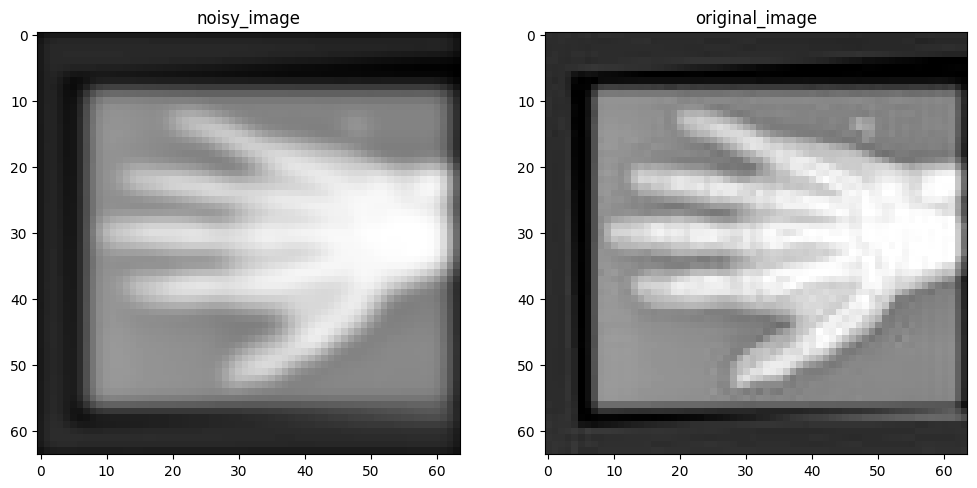

In [ ]:
check_ds = Dataset(data=training_datadict, transform=train_transforms)
check_loader = DataLoader(check_ds, batch_size=1, shuffle=True)
check_data = first(check_loader)
original_image = check_data["original_hand"][0][0]
noisy_image = check_data["noisy_hand"][0][0]

print(f"noisy_image shape: {noisy_image.shape}")
print(f"original_image shape: {original_image.shape}")

plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("noisy_image")
plt.imshow(noisy_image, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("original_image")
plt.imshow(original_image, cmap="gray")

plt.show()

## Create the training pipelines

We use a `CacheDataset` to capture the training pairs and accelerate the training process. The MedNISTDataset provides pairs of "noisy" and "original" images. For demonstration purposes, we treat this as an image restoration problem: the "noisy" image is a degraded version of the "original" reference image (e.g., due to simulated movement or noise). The goal is to restore the noisy image to match the original image.

In [ ]:
train_ds = CacheDataset(data=training_datadict[:1000], transform=train_transforms, cache_rate=1.0, num_workers=0)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)

Loading dataset: 100%|██████████| 1000/1000 [00:00<00:00, 1423.62it/s]


## Model and Training

Now, let's initialize the Restormer model and train it to restore the noisy images. Since this is just a tutorial, we will initialize a small Restormer model with a small size configuration for quick experimentation: 

- `dim=32`: the embedding dimension (feature width) at the first stage.
- `num_blocks=[2, 2]`: 2 encoder and 2 decoder blocks.
- `num_heads=[2, 2]`: 2 attention heads at each stage.
- `refinement=1`: 1 refinement block at the bottleneck.

When training image restoration models, common regression losses include [`MSELoss`](https://deepCLEM.github.io/bioMONAI/losses.html#mseloss), `PSNRLoss`, and `SSIMLoss`. Here, we use `SSIMLoss` because it encourages the model to focus on matching the structural similarity (shape and details) of the hands, rather than just restoring absolute pixel values.

In [ ]:
import torch 
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model = Restormer(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    dim=32,
    num_blocks=[2, 2],
    heads=[2, 2],
    num_refinement_blocks=1,
).to(device)
image_loss = SSIMLoss(spatial_dims=2, data_range=1.0)
optimizer = torch.optim.Adam(model.parameters(), 1e-5)

## The training loops

In [ ]:
import time

max_epochs = 50
epoch_loss_values = []
epoch_times = []  # NEW

for epoch in range(max_epochs):
    epoch_start_time = time.time()  # NEW

    model.train()
    epoch_loss, step = 0, 0

    for batch_data in train_loader:
        step += 1
        optimizer.zero_grad()

        noisy = batch_data["noisy_hand"].to(device)
        original = batch_data["original_hand"].to(device)

        pred_image = model(noisy)
        pred_image = torch.sigmoid(pred_image)

        loss = image_loss(input=pred_image, target=original)
        loss.backward()
        optimizer.step()

        current_loss = loss.item()
        epoch_loss += current_loss

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)

    # TIME CALCULATION
    epoch_time = time.time() - epoch_start_time
    epoch_times.append(epoch_time)

    # PRINT
    print({
        "Epoch": epoch + 1,
        "Avg Epoch Loss": f"{epoch_loss:.4f}",
        "Epoch Time (s)": f"{epoch_time:.2f}"
    })


# FINAL STATS
mean_time = np.mean(epoch_times)
std_time = np.std(epoch_times)

print(f"\nAverage epoch time: {mean_time:.2f} ± {std_time:.2f} seconds")

{'Epoch': 1, 'Avg Epoch Loss': '0.8368', 'Epoch Time (s)': '2.58'}
{'Epoch': 2, 'Avg Epoch Loss': '0.7194', 'Epoch Time (s)': '2.32'}
{'Epoch': 3, 'Avg Epoch Loss': '0.6304', 'Epoch Time (s)': '2.32'}
{'Epoch': 4, 'Avg Epoch Loss': '0.5654', 'Epoch Time (s)': '2.35'}
{'Epoch': 5, 'Avg Epoch Loss': '0.5156', 'Epoch Time (s)': '2.32'}
{'Epoch': 6, 'Avg Epoch Loss': '0.4758', 'Epoch Time (s)': '2.34'}
{'Epoch': 7, 'Avg Epoch Loss': '0.4337', 'Epoch Time (s)': '2.30'}
{'Epoch': 8, 'Avg Epoch Loss': '0.3773', 'Epoch Time (s)': '2.29'}
{'Epoch': 9, 'Avg Epoch Loss': '0.2986', 'Epoch Time (s)': '2.32'}
{'Epoch': 10, 'Avg Epoch Loss': '0.2418', 'Epoch Time (s)': '2.28'}
{'Epoch': 11, 'Avg Epoch Loss': '0.2210', 'Epoch Time (s)': '2.28'}
{'Epoch': 12, 'Avg Epoch Loss': '0.2065', 'Epoch Time (s)': '2.32'}
{'Epoch': 13, 'Avg Epoch Loss': '0.1962', 'Epoch Time (s)': '2.29'}
{'Epoch': 14, 'Avg Epoch Loss': '0.1863', 'Epoch Time (s)': '2.35'}
{'Epoch': 15, 'Avg Epoch Loss': '0.1768', 'Epoch Time (s)

[<matplotlib.lines.Line2D>]

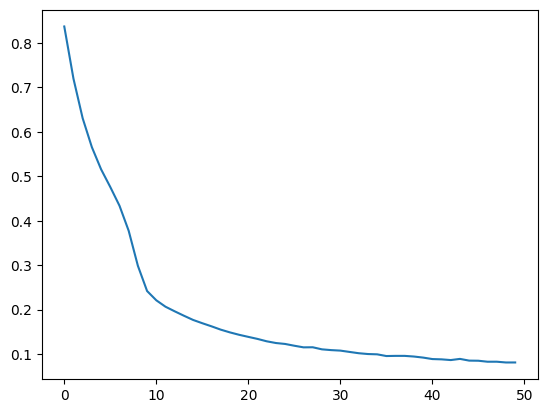

In [ ]:
plt.plot(epoch_loss_values)

In [ ]:
torch.cuda.max_memory_allocated() / 1024**2

2353.0634765625

# Visualise some validation results
This section creates a set of previously unseen pairs of noisy vs original hands,
and use the network to predict the transformation between each pair.

In [ ]:
val_ds = CacheDataset(data=training_datadict[2000:2500], transform=train_transforms, cache_rate=1.0, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=16, num_workers=0)
model.eval()  # Set model to evaluation mode

with torch.no_grad():  # Disable gradient calculation for inference
    for batch_data in val_loader:
        noisy = batch_data["noisy_hand"].to(device)
        original = batch_data["original_hand"].to(device)
        # Pass only the noisy image, consistent with training
        pred_image = model(noisy)
        pred_image = torch.sigmoid(pred_image)
        break  # Process only the first batch for visualization

original_image = original.detach().cpu().numpy()[:, 0]
noisy_image = noisy.detach().cpu().numpy()[:, 0]
pred_image = pred_image.detach().cpu().numpy()[:, 0]

Loading dataset: 100%|██████████| 500/500 [00:00<00:00, 1324.78it/s]


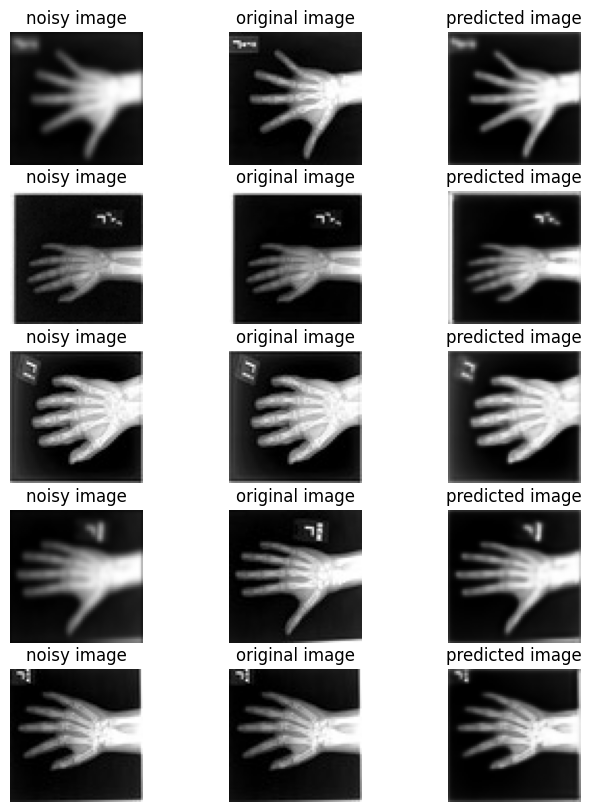

In [ ]:
batch_size = 5
plt.subplots(batch_size, 3, figsize=(8, 10))
for b in range(batch_size):
    # noisy image
    plt.subplot(batch_size, 3, b * 3 + 1)
    plt.axis("off")
    plt.title("noisy image")
    plt.imshow(noisy_image[b], cmap="gray")
    # original image
    plt.subplot(batch_size, 3, b * 3 + 2)
    plt.axis("off")
    plt.title("original image")
    plt.imshow(original_image[b], cmap="gray")
    # predicted restored image
    plt.subplot(batch_size, 3, b * 3 + 3)
    plt.axis("off")
    plt.title("predicted image")
    plt.imshow(pred_image[b], cmap="gray")
plt.axis("off")
plt.show()